<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Preventivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    max_error
)
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

In [ ]:
print(" REGRESION")
df_reg = pd.read_csv('RT_IOT2022_regresion.csv')

if 'Attack Type' in df_reg.columns:
  print("Esta la variable, QUITAR")
else:
  print("No esta la variable, CONTINUAR")

df_reg.shape

 REGRESION
No esta la variable, CONTINUAR


(123117, 79)

In [ ]:
columnas_eliminar = {
    # Tasas que dividen entre flow_duration
    'fwd_pkts_per_sec', 'payload_bytes_per_second',
    'fwd_bulk_rate', 'bwd_bulk_rate',

    # Estadísticas post-facto de flujo completo
    'flow_iat.min', 'flow_iat.avg', 'flow_iat.std',
    'active.min', 'active.max', 'active.tot', 'active.avg', 'active.std',
    'idle.min', 'idle.std',

    # Totales acumulativos al cierre
    'bwd_iat.tot',
    'fwd_pkts_tot', 'fwd_data_pkts_tot',
    'fwd_pkts_payload.tot',
    'fwd_header_size_tot', 'bwd_header_size_tot',
    'bwd_pkts_tot',

    # Leakage estructural confirmado
    'fwd_iat.max', 'bwd_iat.max', 'fwd_iat.min',

    # Variable constante
    'bwd_URG_flag_count',

    #Terminacion tot, todas estas con terminacion tot representan valores de acumulaciones
    'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_pkts_payload.tot', 'fwd_data_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot', 'fwd_pkts_payload.tot', 'bwd_iat.tot',

    # Leakage estructural — acotadas por flow_duration
    'fwd_iat.std', 'fwd_iat.avg',
    'bwd_iat.std', 'bwd_iat.avg',  # verificar estas también

    'fwd_pkts_payload.max', 'fwd_pkts_payload.min', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std',

    'bwd_pkts_payload.max', 'bwd_pkts_payload.min', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std',

    'flow_pkts_payload.max', 'flow_pkts_payload.min', 'flow_pkts_payload.avg', 'flow_pkts_payload.std'
}



df_reg = df_reg.drop(columns=columnas_eliminar, errors='ignore')
df_reg = df_reg[df_reg['flow_duration'] >= 0]

Target = 'flow_duration'
y = df_reg[Target]
X = df_reg.drop(columns=[Target])


In [ ]:
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [ ]:
# Rangos de duración para evaluación segmentada
# Basados en la distribución real del dataset
RANGOS = {
    'Muy corto  (< 0.001s)' : (0,       0.001),
    'Corto      (0.001–1s)' : (0.001,   1.0),
    'Medio      (1s–10s)  ' : (1.0,     10.0),
    'Largo      (10s–60s) ' : (10.0,    60.0),
    'Muy largo  (> 60s)   ' : (60.0,    np.inf),
}

y_test_real = np.expm1(y_test_log)

# Conteo por rango en test
print('Distribución del set de test por rango:')
print(f"{'Rango':<30} {'N':>8} {'%':>8}")
print('-' * 50)
for nombre, (lo, hi) in RANGOS.items():
    mask = (y_test_real >= lo) & (y_test_real < hi)
    n = mask.sum()
    pct = 100 * n / len(y_test_real)
    print(f'{nombre:<30} {n:>8,} {pct:>7.1f}%')
print(f"{'TOTAL':<30} {len(y_test_real):>8,} {'100.0%':>8}")

Distribución del set de test por rango:
Rango                                 N        %
--------------------------------------------------
Muy corto  (< 0.001s)            21,259    86.3%
Corto      (0.001–1s)             1,824     7.4%
Medio      (1s–10s)                 415     1.7%
Largo      (10s–60s)                691     2.8%
Muy largo  (> 60s)                  435     1.8%
TOTAL                            24,624   100.0%


Modelo Light GBM

In [ ]:
modelo_reg_GBM = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_bin=255,
    min_data_in_leaf=5,
    num_leaves=63,
    verbose=-1
)

modelo_reg_GBM.fit(X_train, y_train_log)

pred_GBM = modelo_reg_GBM.predict(X_test)

pred_GBM_real = np.expm1(np.clip(pred_GBM, -np.inf, 10))
pred_GBM_real = np.clip(pred_GBM_real, 0, None)
y_test_original_GBM = np.expm1(y_test_log)

# --- MÉTRICAS EN ESCALA LOG ---
mae_GBM_log  = mean_absolute_error(y_test_log, pred_GBM)
mse_GBM_log  = mean_squared_error(y_test_log, pred_GBM)
rmse_GBM_log = np.sqrt(mse_GBM_log)
r2_GBM_log   = r2_score(y_test_log, pred_GBM)

# --- MÉTRICAS EN ESCALA REAL ---
mae_GBM  = mean_absolute_error(y_test_original_GBM, pred_GBM_real)
mse_GBM  = mean_squared_error(y_test_original_GBM, pred_GBM_real)
rmse_GBM = np.sqrt(mse_GBM)
r2_GBM   = r2_score(y_test_original_GBM, pred_GBM_real)

print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  : {mae_GBM_log:.6f}")
print(f"  RMSE : {rmse_GBM_log:.6f}")
print(f"  R²   : {r2_GBM_log:.6f}")
print(f"\n  — Escala real (segundos) —")
print(f"  MAE  : {mae_GBM:.6f}")
print(f"  RMSE : {rmse_GBM:.6f}")
print(f"  R²   : {r2_GBM:.6f}")


  — Escala logarítmica (log1p) —
  MAE  : 0.030112
  RMSE : 0.174285
  R²   : 0.954172

  — Escala real (segundos) —
  MAE  : 1.000908
  RMSE : 12.861093
  R²   : 0.464061


Entrenaiento para flujos largos

In [ ]:
def evaluar_por_rangos(y_real, y_pred_real, y_real_log, y_pred_log, nombre_modelo):
    """Evalúa métricas separadas por rango de duración del flujo."""
    print(f'\n{"="*70}')
    print(f'  EVALUACIÓN POR RANGOS — {nombre_modelo}')
    print(f'{"="*70}')
    print(f"{'Rango':<28} {'N':>6} {'R²':>8} {'MAE(s)':>10} {'RMSE(s)':>10} {'MAPE%':>8}")
    print('-' * 70)

    resultados = {}
    for nombre, (lo, hi) in RANGOS.items():
        mask = (y_real >= lo) & (y_real < hi)
        n = mask.sum()
        if n < 5:
            print(f'{nombre:<28} {n:>6}   (insuficiente)')
            continue

        yr = y_real[mask]
        yp = y_pred_real[mask]

        r2   = r2_score(yr, yp)
        mae  = mean_absolute_error(yr, yp)
        rmse = np.sqrt(mean_squared_error(yr, yp))
        # MAPE evitando división por cero
        nonzero = yr > 1e-9
        mape = np.mean(np.abs((yr[nonzero] - yp[nonzero]) / yr[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

        resultados[nombre.strip()] = {'n': n, 'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}
        print(f'{nombre:<28} {n:>6} {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f} {mape:>7.1f}%')

    print('-' * 70)
    r2_global   = r2_score(y_real, y_pred_real)
    mae_global  = mean_absolute_error(y_real, y_pred_real)
    rmse_global = np.sqrt(mean_squared_error(y_real, y_pred_real))
    print(f"{'GLOBAL':<28} {len(y_real):>6} {r2_global:>8.4f} {mae_global:>10.4f} {rmse_global:>10.4f}")

    return resultados

resultados_base = evaluar_por_rangos(
    y_test_real.values, pred_GBM_real,
    y_test_log.values, pred_GBM,
    'LightGBM Base (V2)'
)


  EVALUACIÓN POR RANGOS — LightGBM Base (V2)
Rango                             N       R²     MAE(s)    RMSE(s)    MAPE%
----------------------------------------------------------------------
Muy corto  (< 0.001s)         21259 -3201703.8478     0.0029     0.0914  5949.3%
Corto      (0.001–1s)          1824   0.1108     0.0831     0.3357   164.4%
Medio      (1s–10s)             415 -26.1054     5.3355    12.2924   106.4%
Largo      (10s–60s)            691 -13.9750    12.1505    53.8640    53.7%
Muy largo  (> 60s)              435   0.3586    31.7783    67.8926    32.6%
----------------------------------------------------------------------
GLOBAL                        24624   0.4641     1.0009    12.8611


Definicion de umbral

In [ ]:
# Umbral a partir del cual activamos el modelo especializado
UMBRAL_LARGO = 1.0  # segundos

# Seleccionar filas de train donde flow_duration > UMBRAL_LARGO
y_train_real = np.expm1(y_train_log)
mask_largo_train = y_train_real > UMBRAL_LARGO

X_train_largo  = X_train[mask_largo_train]
y_train_largo  = y_train_log[mask_largo_train]

print(f'Flujos de entrenamiento totales    : {len(X_train):,}')
print(f'Flujos largos (>{UMBRAL_LARGO}s) en train: {mask_largo_train.sum():,} ({100*mask_largo_train.mean():.1f}%)')

# Modelo especializado — más árboles, más profundo, regularización más fuerte
modelo_largo = LGBMRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_bin=255,
    min_data_in_leaf=3,
    num_leaves=127,
    learning_rate=0.03,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1
)

modelo_largo.fit(X_train_largo, y_train_largo)
print('Modelo especializado entrenado.')

Flujos de entrenamiento totales    : 98,493
Flujos largos (>1.0s) en train: 5,913 (6.0%)
Modelo especializado entrenado.


In [ ]:
def predecir_hibrido(X_input, modelo_base, modelo_largo, umbral_log):
    """
    Sistema de predicción en dos etapas:
    1. Modelo base predice para todos los flujos.
    2. Si la predicción base > umbral_log, el modelo especializado
       refina la predicción (promedio ponderado).
    """
    pred_base = modelo_reg_GBM.predict(X_input)

    # Máscara de flujos donde el modelo base estima duración larga
    mask_largo = pred_base > umbral_log

    pred_final = pred_base.copy()

    if mask_largo.sum() > 0:
        # El modelo especializado refina estos flujos
        if hasattr(X_input, 'iloc'):
            X_largo = X_input.iloc[mask_largo]
        else:
            X_largo = X_input[mask_largo]

        pred_especializado = modelo_largo.predict(X_largo)

        # Promedio ponderado: 40% base + 60% especializado
        pred_final[mask_largo] = (
            0.4 * pred_base[mask_largo] +
            0.6 * pred_especializado
        )

    return pred_final, mask_largo


umbral_log = np.log1p(UMBRAL_LARGO)

pred_hibrido_log, mask_largo_test = predecir_hibrido(
    X_test, modelo_reg_GBM, modelo_largo, umbral_log
)

pred_hibrido_real = np.expm1(np.clip(pred_hibrido_log, -np.inf, 10))
pred_hibrido_real = np.clip(pred_hibrido_real, 0, None)

print(f'Flujos en test activaron modelo especializado: {mask_largo_test.sum():,} ({100*mask_largo_test.mean():.1f}%)')

resultados_hibrido = evaluar_por_rangos(
    y_test_real.values, pred_hibrido_real,
    y_test_log.values, pred_hibrido_log,
    'Sistema Híbrido (base + especializado)'
)

Flujos en test activaron modelo especializado: 1,560 (6.3%)

  EVALUACIÓN POR RANGOS — Sistema Híbrido (base + especializado)
Rango                             N       R²     MAE(s)    RMSE(s)    MAPE%
----------------------------------------------------------------------
Muy corto  (< 0.001s)         21259 -28224678.4036     0.0067     0.2714  7287.8%
Corto      (0.001–1s)          1824  -3.0678     0.1267     0.7181   216.5%
Medio      (1s–10s)             415 -27.0755     5.3866    12.5104   107.4%
Largo      (10s–60s)            691 -19.0608    12.3051    62.3431    54.1%
Muy largo  (> 60s)              435   0.4487    30.4365    62.9444    31.6%
----------------------------------------------------------------------
GLOBAL                        24624   0.4110     0.9889    13.4833


In [ ]:
def calcular_score_riesgo(
    pred_GBM,
    pred_GBM_real,
    y_train_log,
    margen_tolerancia=1.5,
    segundos_gracia=0.5,
    percentil_alarma=90
):
    """
    Genera un score de riesgo preventivo entre 0 y 100.

    Componentes:
    A) Score de umbral: qué tan cerca está el flujo de superar el tiempo permitido
    B) Score de percentil: qué tan inusual es la duración predicha en el historial de entrenamiento

    Returns
    -------
    score         : array float [0, 100]
    alerta        : array bool  — True si score >= percentil_alarma
    tiempo_limite : array float — tiempo máximo permitido en segundos
    """
    # --- Componente A: umbral de tiempo ---
    tiempo_limite = (pred_GBM_real * margen_tolerancia) + segundos_gracia

    # Ratio de exceso en escala log: log(pred) / log(límite)
    # Cuando pred ≈ límite → ratio ≈ 1 → score_umbral ≈ 100
    log_limite = np.log1p(tiempo_limite)
    ratio = np.clip(pred_GBM / (log_limite + 1e-9), 0, 2)
    score_umbral = np.clip(ratio * 100, 0, 100)

    # --- Componente B: percentil histórico ---
    # ¿Qué percentil ocupa esta predicción dentro del historial de train?
    y_train_sorted = np.sort(y_train_log)
    score_percentil = np.array([
        np.searchsorted(y_train_sorted, p) / len(y_train_sorted) * 100
        for p in pred_GBM
    ])

    # --- Score final: promedio ponderado ---
    score = 0.6 * score_umbral + 0.4 * score_percentil
    score = np.clip(score, 0, 100)

    alerta = score >= percentil_alarma

    return score, alerta, tiempo_limite


score_riesgo, alertas, tiempo_limite = calcular_score_riesgo(
    pred_hibrido_log,
    pred_hibrido_real,
    y_train_log.values
)

print(f'Flujos con ALERTA (score >= 90): {alertas.sum():,} ({100*alertas.mean():.1f}%)')
print(f'Score promedio de riesgo      : {score_riesgo.mean():.2f}')
print(f'Score mediana de riesgo       : {np.median(score_riesgo):.2f}')
print(f'Score máximo                  : {score_riesgo.max():.2f}')

Flujos con ALERTA (score >= 90): 1,125 (4.6%)
Score promedio de riesgo      : 39.19
Score mediana de riesgo       : 34.09
Score máximo                  : 96.87


In [ ]:
# Definimos "ataque candidato" como flujo real > UMBRAL_LARGO
flujo_largo_real = (y_test_real.values > UMBRAL_LARGO)

# Métricas de detección del sistema preventivo
verdaderos_positivos  = (alertas & flujo_largo_real).sum()
falsos_positivos      = (alertas & ~flujo_largo_real).sum()
falsos_negativos      = (~alertas & flujo_largo_real).sum()
verdaderos_negativos  = (~alertas & ~flujo_largo_real).sum()

precision  = verdaderos_positivos / (verdaderos_positivos + falsos_positivos + 1e-9)
recall     = verdaderos_positivos / (verdaderos_positivos + falsos_negativos + 1e-9)
f1         = 2 * precision * recall / (precision + recall + 1e-9)
tasa_fp    = falsos_positivos / (~flujo_largo_real).sum()

print('\n' + '='*52)
print('  VALIDACIÓN DEL SISTEMA PREVENTIVO')
print('='*52)
print(f'  Umbral de alerta            : score >= 90')
print(f'  Flujos "largos" reales       : {flujo_largo_real.sum():,}')
print(f'  Alertas generadas           : {alertas.sum():,}')
print()
print(f'  Verdaderos Positivos (VP)   : {verdaderos_positivos:,}')
print(f'  Falsos Positivos    (FP)    : {falsos_positivos:,}')
print(f'  Falsos Negativos    (FN)    : {falsos_negativos:,}')
print(f'  Verdaderos Negativos(VN)    : {verdaderos_negativos:,}')
print()
print(f'  Precisión                   : {precision:.4f}')
print(f'  Recall (Sensibilidad)       : {recall:.4f}')
print(f'  F1-Score                    : {f1:.4f}')
print(f'  Tasa de Falsos Positivos    : {tasa_fp:.4f}')
print('='*52)


  VALIDACIÓN DEL SISTEMA PREVENTIVO
  Umbral de alerta            : score >= 90
  Flujos "largos" reales       : 1,541
  Alertas generadas           : 1,125

  Verdaderos Positivos (VP)   : 1,121
  Falsos Positivos    (FP)    : 4
  Falsos Negativos    (FN)    : 420
  Verdaderos Negativos(VN)    : 23,079

  Precisión                   : 0.9964
  Recall (Sensibilidad)       : 0.7274
  F1-Score                    : 0.8410
  Tasa de Falsos Positivos    : 0.0002


In [ ]:
umbrales = np.arange(50, 100, 2)
resultados_umbral = []

for u in umbrales:
    alerta_u = score_riesgo >= u
    vp = (alerta_u & flujo_largo_real).sum()
    fp = (alerta_u & ~flujo_largo_real).sum()
    fn = (~alerta_u & flujo_largo_real).sum()
    prec = vp / (vp + fp + 1e-9)
    rec  = vp / (vp + fn + 1e-9)
    f1_u = 2 * prec * rec / (prec + rec + 1e-9)
    resultados_umbral.append({
        'umbral': u, 'alertas': alerta_u.sum(),
        'precision': prec, 'recall': rec, 'f1': f1_u
    })

df_umbral = pd.DataFrame(resultados_umbral)
mejor = df_umbral.loc[df_umbral['f1'].idxmax()]

print('Análisis de umbrales:')
print(f"{'Umbral':>8} {'Alertas':>9} {'Precisión':>11} {'Recall':>8} {'F1':>8}")
print('-' * 50)
for _, row in df_umbral.iterrows():
    marca = ' ← MEJOR' if row['umbral'] == mejor['umbral'] else ''
    print(f"{row['umbral']:>8.0f} {row['alertas']:>9.0f} {row['precision']:>11.4f} {row['recall']:>8.4f} {row['f1']:>8.4f}{marca}")

print(f'\nMejor umbral: {mejor["umbral"]:.0f} (F1={mejor["f1"]:.4f})')

Análisis de umbrales:
  Umbral   Alertas   Precisión   Recall       F1
--------------------------------------------------
      50      2315      0.6644   0.9981   0.7977
      52      2288      0.6718   0.9974   0.8028
      54      2283      0.6732   0.9974   0.8039
      56      2237      0.6862   0.9961   0.8126
      58      2231      0.6880   0.9961   0.8139
      60      2215      0.6930   0.9961   0.8174
      62      2205      0.6961   0.9961   0.8195
      64      2189      0.7008   0.9955   0.8225
      66      2171      0.7066   0.9955   0.8265
      68      2157      0.7112   0.9955   0.8296
      70      2149      0.7129   0.9942   0.8304
      72      2127      0.7184   0.9916   0.8332
      74      1571      0.9656   0.9844   0.9749
      76      1560      0.9692   0.9812   0.9752 ← MEJOR
      78      1544      0.9715   0.9734   0.9724
      80      1338      0.9679   0.8404   0.8996
      82      1329      0.9691   0.8358   0.8976
      84      1321      0.9705   0.83

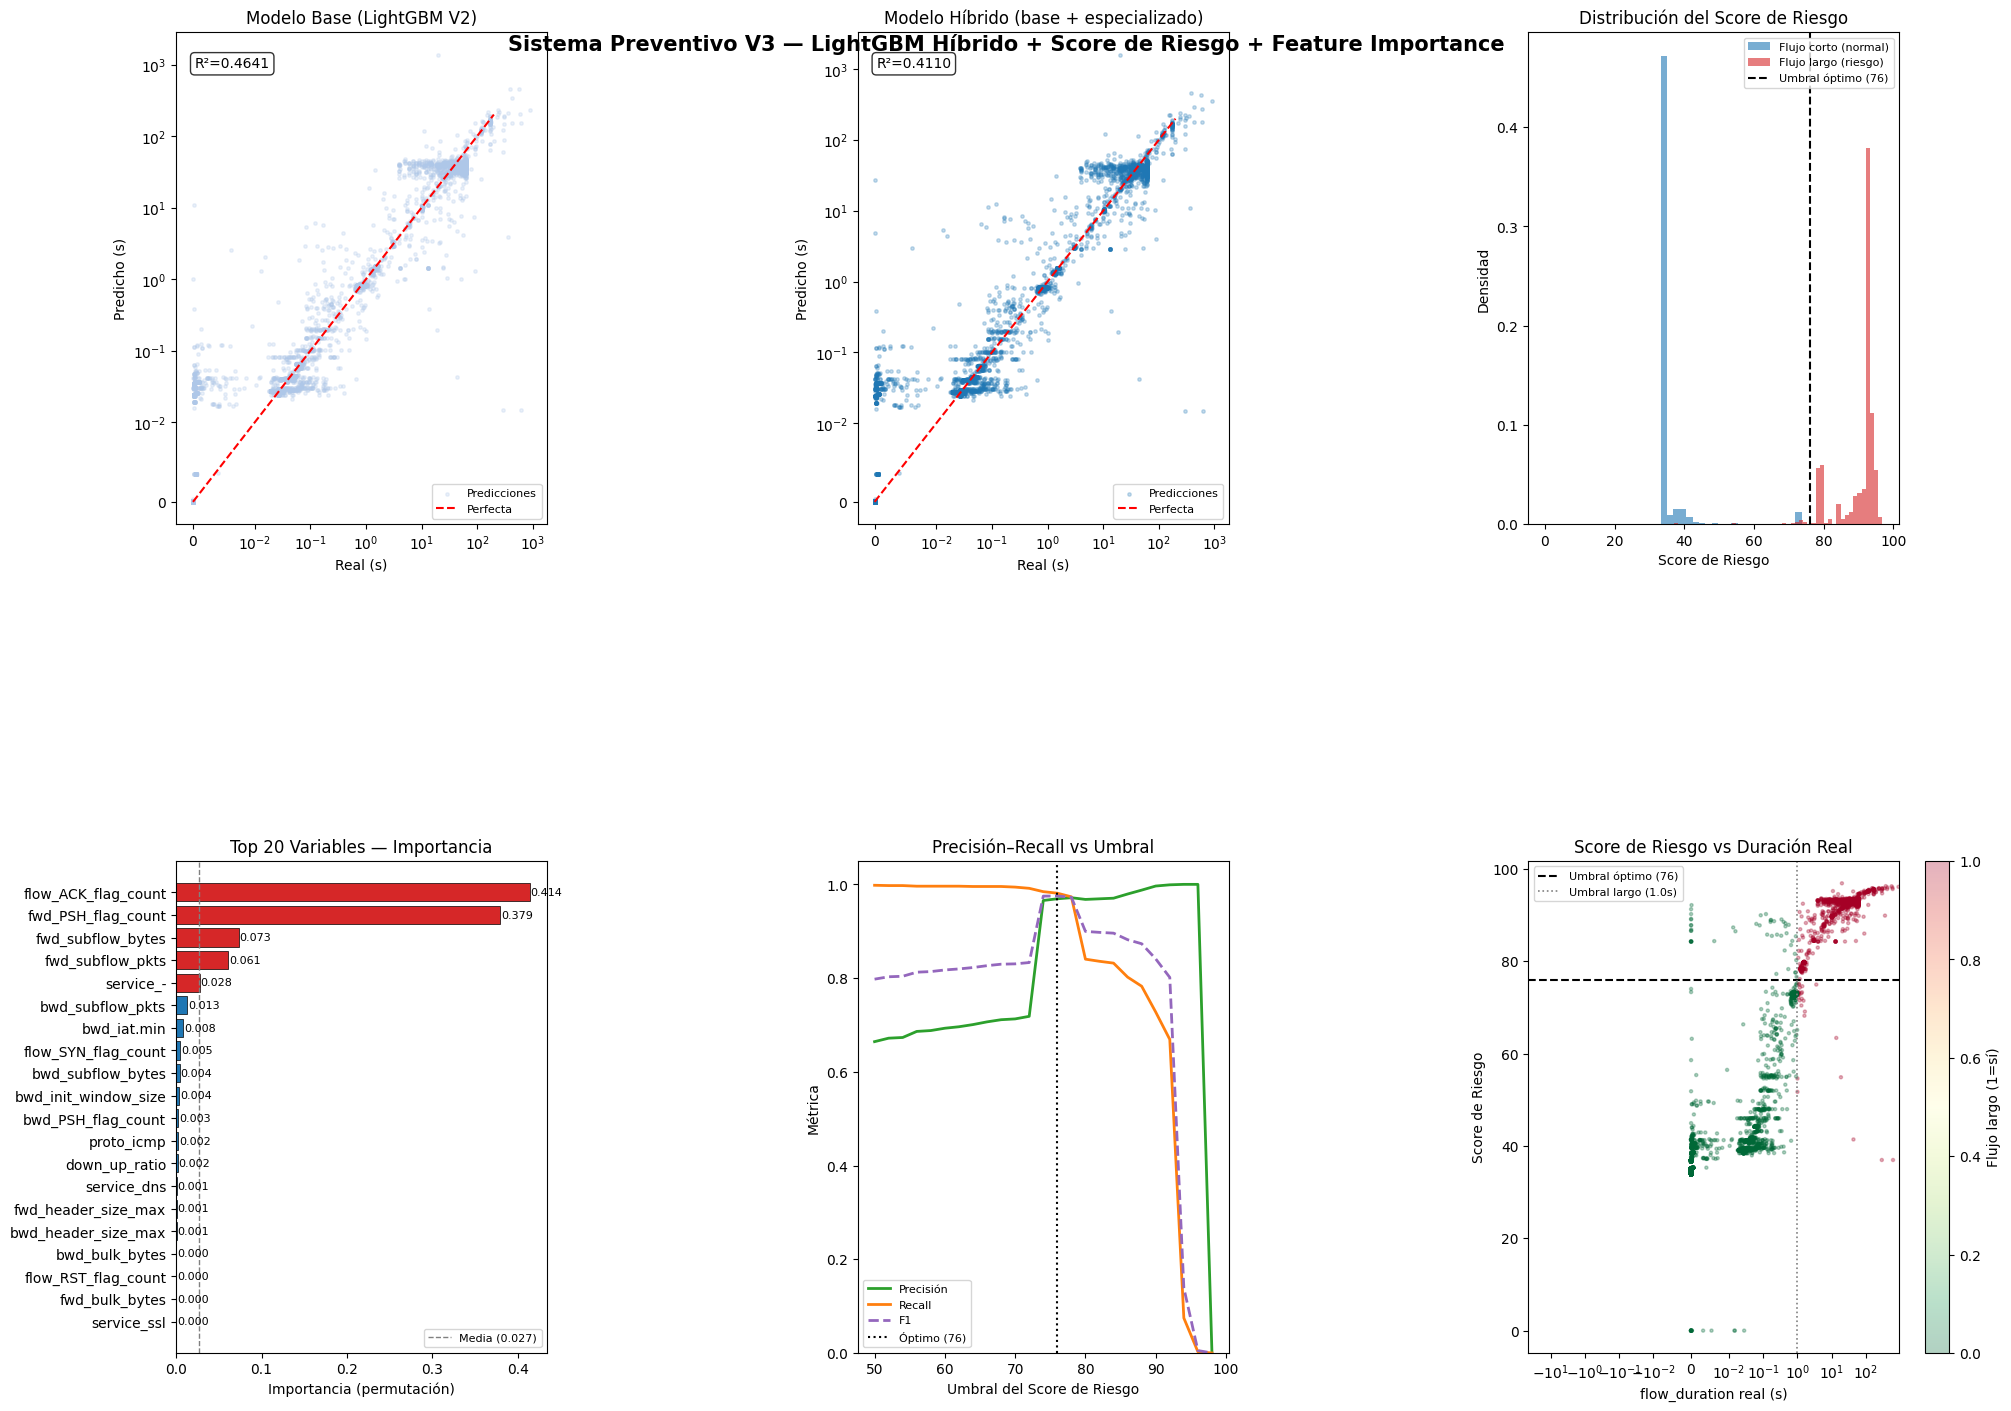

In [ ]:
fig = plt.figure(figsize=(20, 14), constrained_layout=True)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

fig.suptitle(
    'Sistema Preventivo V3 — LightGBM Híbrido + Score de Riesgo + Feature Importance',
    fontsize=15, fontweight='bold', y=0.98
)

# ── Colores ──────────────────────────────────────────────────────────────
C_NORMAL  = '#1f77b4'
C_ALERTA  = '#d62728'
C_BASE    = '#aec7e8'
C_HIBRIDO = '#1f77b4'

# ─── Panel 1: Real vs Predicho — Modelo Base ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
mask_pos = (y_test_real.values > 0) & (pred_GBM_real > 0)
ax1.scatter(y_test_real.values[mask_pos], pred_GBM_real[mask_pos],
            alpha=0.25, s=6, color=C_BASE, label='Predicciones')
lim = [0, min(y_test_real.values[mask_pos].max(), 200)]
ax1.plot(lim, lim, 'r--', lw=1.5, label='Perfecta')
ax1.set_xscale('symlog', linthresh=0.01)
ax1.set_yscale('symlog', linthresh=0.01)
ax1.set_xlabel('Real (s)')
ax1.set_ylabel('Predicho (s)')
ax1.set_title('Modelo Base (LightGBM V2)')
r2_b = r2_score(y_test_real.values, pred_GBM_real)
ax1.text(0.05, 0.95, f'R²={r2_b:.4f}', transform=ax1.transAxes,
         va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8), fontsize=10)
ax1.legend(fontsize=8)

# ─── Panel 2: Real vs Predicho — Modelo Híbrido ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test_real.values[mask_pos], pred_hibrido_real[mask_pos],
            alpha=0.25, s=6, color=C_HIBRIDO, label='Predicciones')
ax2.plot(lim, lim, 'r--', lw=1.5, label='Perfecta')
ax2.set_xscale('symlog', linthresh=0.01)
ax2.set_yscale('symlog', linthresh=0.01)
ax2.set_xlabel('Real (s)')
ax2.set_ylabel('Predicho (s)')
ax2.set_title('Modelo Híbrido (base + especializado)')
r2_h = r2_score(y_test_real.values, pred_hibrido_real)
ax2.text(0.05, 0.95, f'R²={r2_h:.4f}', transform=ax2.transAxes,
         va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8), fontsize=10)
ax2.legend(fontsize=8)

# ─── Panel 3: Score de riesgo — distribución ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(score_riesgo[~flujo_largo_real], bins=50, alpha=0.6,
         color=C_NORMAL, label='Flujo corto (normal)', density=True)
ax3.hist(score_riesgo[flujo_largo_real],  bins=50, alpha=0.6,
         color=C_ALERTA, label='Flujo largo (riesgo)', density=True)
ax3.axvline(mejor['umbral'], color='black', linestyle='--', lw=1.5,
            label=f'Umbral óptimo ({mejor["umbral"]:.0f})')
ax3.set_xlabel('Score de Riesgo')
ax3.set_ylabel('Densidad')
ax3.set_title('Distribución del Score de Riesgo')
ax3.legend(fontsize=8)

# ─── Panel 4: Feature Importances ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

# NOTA: Asegúrate de reemplazar 'modelo_base' o los datos de entrenamiento
# por la variable real que uses para tu modelo LightGBM.
perm_fi = permutation_importance(
    modelo_reg_GBM, X_train, y_train_log, # <-- ACTUALIZAR AQUÍ si cambió de nombre
    n_repeats=5, random_state=42, n_jobs=1,
    scoring='r2'
)
importancias_fi = np.clip(perm_fi.importances_mean, 0, None)
importancias_fi = importancias_fi / importancias_fi.sum() if importancias_fi.sum() > 0 else importancias_fi
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20

top_nombres_fi = [nombres[i] for i in indices_fi[:top_n]][::-1]
top_valores_fi = importancias_fi[indices_fi[:top_n]][::-1]
colores_fi     = ['#d62728' if v > importancias_fi.mean() else '#1f77b4' for v in top_valores_fi]

ax4.barh(top_nombres_fi, top_valores_fi, color=colores_fi, edgecolor='black', linewidth=0.5)
ax4.axvline(x=importancias_fi.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Media ({importancias_fi.mean():.3f})')
ax4.set_xlabel('Importancia (permutación)')
ax4.set_title(f'Top {top_n} Variables — Importancia')
ax4.legend(fontsize=8)
for i, v in enumerate(top_nombres_fi):
    ax4.text(top_valores_fi[i] + 0.001, i, f'{top_valores_fi[i]:.3f}', va='center', fontsize=8)

# ─── Panel 5: Precisión–Recall por umbral de score ───────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(df_umbral['umbral'], df_umbral['precision'], label='Precisión', color='#2ca02c', lw=2)
ax5.plot(df_umbral['umbral'], df_umbral['recall'],    label='Recall',    color='#ff7f0e', lw=2)
ax5.plot(df_umbral['umbral'], df_umbral['f1'],        label='F1',        color='#9467bd', lw=2, linestyle='--')
ax5.axvline(mejor['umbral'], color='black', linestyle=':', lw=1.5,
            label=f'Óptimo ({mejor["umbral"]:.0f})')
ax5.set_xlabel('Umbral del Score de Riesgo')
ax5.set_ylabel('Métrica')
ax5.set_title('Precisión–Recall vs Umbral')
ax5.legend(fontsize=8)
ax5.set_ylim(0, 1.05)

# ─── Panel 6: Score de riesgo vs duración real ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(
    y_test_real.values, score_riesgo,
    c=flujo_largo_real.astype(int), cmap='RdYlGn_r',
    alpha=0.3, s=5
)
ax6.axhline(mejor['umbral'], color='black', linestyle='--', lw=1.5,
            label=f'Umbral óptimo ({mejor["umbral"]:.0f})')
ax6.axvline(UMBRAL_LARGO, color='gray', linestyle=':', lw=1.2,
            label=f'Umbral largo ({UMBRAL_LARGO}s)')
ax6.set_xscale('symlog', linthresh=0.01)
ax6.set_xlabel('flow_duration real (s)')
ax6.set_ylabel('Score de Riesgo')
ax6.set_title('Score de Riesgo vs Duración Real')
ax6.legend(fontsize=8)
plt.colorbar(sc, ax=ax6, label='Flujo largo (1=sí)')

plt.show()

Gradient boosting

In [ ]:
# --- MODELO ---
modelo_reg_gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,      # equivalente a max_iter
    random_state=42,
    learning_rate=0.05,
    max_depth=5,
    alpha=0.1             # equivalente a l2_regularization (usa alpha para regularización)
)

modelo_reg_gradient_boosting.fit(X_train, y_train_log)

# --- PREDECIR ---
pred_log = modelo_reg_gradient_boosting.predict(X_test)

# Se regresa los valores a segundos
predicciones_tiempo_gradient = np.expm1(np.clip(pred_log, -np.inf, 10))
predicciones_tiempo_gradient = np.clip(predicciones_tiempo_gradient, 0, None)
y_test_original = np.expm1(y_test_log)

# --- MÉTRICAS EN ESCALA LOG ---
mae_gradient_log  = mean_absolute_error(y_test_log, pred_log)
mse_gradient_log  = mean_squared_error(y_test_log, pred_log)
rmse_gradient_log = np.sqrt(mse_gradient_log)
r2_gradient_log   = r2_score(y_test_log, pred_log)

# --- MÉTRICAS EN ESCALA REAL ---
mae_gradient  = mean_absolute_error(y_test_original, predicciones_tiempo_gradient)
mse_gradient  = mean_squared_error(y_test_original, predicciones_tiempo_gradient)
rmse_gradient = np.sqrt(mse_gradient)
r2_gradient   = r2_score(y_test_original, predicciones_tiempo_gradient)

print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  : {mae_gradient_log:.6f}")
print(f"  RMSE : {rmse_gradient_log:.6f}")
print(f"  R²   : {r2_gradient_log:.6f}")
print(f"\n  — Escala real (segundos) —")
print(f"  MAE  : {mae_gradient:.6f}")
print(f"  RMSE : {rmse_gradient:.6f}")
print(f"  R²   : {r2_gradient:.6f}")


  — Escala logarítmica (log1p) —
  MAE  : 0.035876
  RMSE : 0.185426
  R²   : 0.948126

  — Escala real (segundos) —
  MAE  : 1.029402
  RMSE : 10.038894
  R²   : 0.673464


In [ ]:
resultados_base_GradientBoosting = evaluar_por_rangos(
    y_test_real.values, predicciones_tiempo_gradient,
    y_test_log.values, pred_log,
    'Gradient Boosting'
)




  EVALUACIÓN POR RANGOS — Gradient Boosting
Rango                             N       R²     MAE(s)    RMSE(s)    MAPE%
----------------------------------------------------------------------
Muy corto  (< 0.001s)         21259 -3518409.0641     0.0054     0.0958 115467.9%
Corto      (0.001–1s)          1824   0.1822     0.0959     0.3220   234.5%
Medio      (1s–10s)             415 -24.4726     5.3874    11.9164   106.8%
Largo      (10s–60s)            691  -0.3309    10.7546    16.0581    46.2%
Muy largo  (> 60s)              435   0.2822    35.3809    71.8250    35.7%
----------------------------------------------------------------------
GLOBAL                        24624   0.6735     1.0294    10.0389


In [ ]:
def predecir_hibrido(X_input, modelo_base, modelo_largo, umbral_log):
    """
    Sistema de predicción en dos etapas:
    1. Modelo base predice para todos los flujos.
    2. Si la predicción base > umbral_log, el modelo especializado
       refina la predicción (promedio ponderado).
    """
    pred_base = modelo_reg_gradient_boosting.predict(X_input)

    # Máscara de flujos donde el modelo base estima duración larga
    mask_largo = pred_base > umbral_log

    pred_final = pred_base.copy()

    if mask_largo.sum() > 0:
        # El modelo especializado refina estos flujos
        if hasattr(X_input, 'iloc'):
            X_largo = X_input.iloc[mask_largo]
        else:
            X_largo = X_input[mask_largo]

        pred_especializado = modelo_largo.predict(X_largo)

        # Promedio ponderado: 40% base + 60% especializado
        pred_final[mask_largo] = (
            0.4 * pred_base[mask_largo] +
            0.6 * pred_especializado
        )

    return pred_final, mask_largo


umbral_log = np.log1p(UMBRAL_LARGO)

pred_hibrido_log, mask_largo_test = predecir_hibrido(
    X_test, modelo_reg_gradient_boosting, modelo_largo, umbral_log
)

pred_hibrido_real = np.expm1(np.clip(pred_hibrido_log, -np.inf, 10))
pred_hibrido_real = np.clip(pred_hibrido_real, 0, None)

print(f'Flujos en test activaron modelo especializado: {mask_largo_test.sum():,} ({100*mask_largo_test.mean():.1f}%)')

resultados_hibrido = evaluar_por_rangos(
    y_test_real.values, pred_hibrido_real,
    y_test_log.values, pred_hibrido_log,
    'Sistema Híbrido (base + especializado)'
)

Flujos en test activaron modelo especializado: 1,541 (6.3%)

  EVALUACIÓN POR RANGOS — Sistema Híbrido (base + especializado)
Rango                             N       R²     MAE(s)    RMSE(s)    MAPE%
----------------------------------------------------------------------
Muy corto  (< 0.001s)         21259 -34464179.3223     0.0087     0.2999 116197.4%
Corto      (0.001–1s)          1824  -3.0744     0.1464     0.7187   290.2%
Medio      (1s–10s)             415 -26.1656     5.4123    12.3060   107.8%
Largo      (10s–60s)            691  -2.7298    10.9927    26.8818    47.6%
Muy largo  (> 60s)              435   0.4053    32.0588    65.3763    33.0%
----------------------------------------------------------------------
GLOBAL                        24624   0.6810     0.9844     9.9222


In [ ]:
def calcular_score_riesgo(
    pred_log,
    predicciones_tiempo_gradient,
    y_train_log,
    margen_tolerancia=1.5,
    segundos_gracia=0.5,
    percentil_alarma=90
):
    """
    Genera un score de riesgo preventivo entre 0 y 100.

    Componentes:
    A) Score de umbral: qué tan cerca está el flujo de superar el tiempo permitido
    B) Score de percentil: qué tan inusual es la duración predicha en el historial de entrenamiento

    Returns
    -------
    score         : array float [0, 100]
    alerta        : array bool  — True si score >= percentil_alarma
    tiempo_limite : array float — tiempo máximo permitido en segundos
    """
    # --- Componente A: umbral de tiempo ---
    tiempo_limite = (predicciones_tiempo_gradient * margen_tolerancia) + segundos_gracia

    # Ratio de exceso en escala log: log(pred) / log(límite)
    # Cuando pred ≈ límite → ratio ≈ 1 → score_umbral ≈ 100
    log_limite = np.log1p(tiempo_limite)
    ratio = np.clip(pred_log / (log_limite + 1e-9), 0, 2)
    score_umbral = np.clip(ratio * 100, 0, 100)

    # --- Componente B: percentil histórico ---
    # ¿Qué percentil ocupa esta predicción dentro del historial de train?
    y_train_sorted = np.sort(y_train_log)
    score_percentil = np.array([
        np.searchsorted(y_train_sorted, p) / len(y_train_sorted) * 100
        for p in pred_log
    ])

    # --- Score final: promedio ponderado ---
    score = 0.6 * score_umbral + 0.4 * score_percentil
    score = np.clip(score, 0, 100)

    alerta = score >= percentil_alarma

    return score, alerta, tiempo_limite


score_riesgo, alertas, tiempo_limite = calcular_score_riesgo(
    pred_hibrido_log,
    pred_hibrido_real,
    y_train_log.values
)

print(f'Flujos con ALERTA (score >= 90): {alertas.sum():,} ({100*alertas.mean():.1f}%)')
print(f'Score promedio de riesgo      : {score_riesgo.mean():.2f}')
print(f'Score mediana de riesgo       : {np.median(score_riesgo):.2f}')
print(f'Score máximo                  : {score_riesgo.max():.2f}')

Flujos con ALERTA (score >= 90): 1,116 (4.5%)
Score promedio de riesgo      : 40.06
Score mediana de riesgo       : 35.08
Score máximo                  : 96.42


In [ ]:
# Definimos "ataque candidato" como flujo real > UMBRAL_LARGO
flujo_largo_real = (y_test_real.values > UMBRAL_LARGO)

# Métricas de detección del sistema preventivo
verdaderos_positivos  = (alertas & flujo_largo_real).sum()
falsos_positivos      = (alertas & ~flujo_largo_real).sum()
falsos_negativos      = (~alertas & flujo_largo_real).sum()
verdaderos_negativos  = (~alertas & ~flujo_largo_real).sum()

precision  = verdaderos_positivos / (verdaderos_positivos + falsos_positivos + 1e-9)
recall     = verdaderos_positivos / (verdaderos_positivos + falsos_negativos + 1e-9)
f1         = 2 * precision * recall / (precision + recall + 1e-9)
tasa_fp    = falsos_positivos / (~flujo_largo_real).sum()

print('\n' + '='*52)
print('  VALIDACIÓN DEL SISTEMA PREVENTIVO')
print('='*52)
print(f'  Umbral de alerta            : score >= 90')
print(f'  Flujos "largos" reales       : {flujo_largo_real.sum():,}')
print(f'  Alertas generadas           : {alertas.sum():,}')
print()
print(f'  Verdaderos Positivos (VP)   : {verdaderos_positivos:,}')
print(f'  Falsos Positivos    (FP)    : {falsos_positivos:,}')
print(f'  Falsos Negativos    (FN)    : {falsos_negativos:,}')
print(f'  Verdaderos Negativos(VN)    : {verdaderos_negativos:,}')
print()
print(f'  Precisión                   : {precision:.4f}')
print(f'  Recall (Sensibilidad)       : {recall:.4f}')
print(f'  F1-Score                    : {f1:.4f}')
print(f'  Tasa de Falsos Positivos    : {tasa_fp:.4f}')
print('='*52)


  VALIDACIÓN DEL SISTEMA PREVENTIVO
  Umbral de alerta            : score >= 90
  Flujos "largos" reales       : 1,541
  Alertas generadas           : 1,116

  Verdaderos Positivos (VP)   : 1,113
  Falsos Positivos    (FP)    : 3
  Falsos Negativos    (FN)    : 428
  Verdaderos Negativos(VN)    : 23,080

  Precisión                   : 0.9973
  Recall (Sensibilidad)       : 0.7223
  F1-Score                    : 0.8378
  Tasa de Falsos Positivos    : 0.0001


In [ ]:
umbrales = np.arange(50, 100, 2)
resultados_umbral = []

for u in umbrales:
    alerta_u = score_riesgo >= u
    vp = (alerta_u & flujo_largo_real).sum()
    fp = (alerta_u & ~flujo_largo_real).sum()
    fn = (~alerta_u & flujo_largo_real).sum()
    prec = vp / (vp + fp + 1e-9)
    rec  = vp / (vp + fn + 1e-9)
    f1_u = 2 * prec * rec / (prec + rec + 1e-9)
    resultados_umbral.append({
        'umbral': u, 'alertas': alerta_u.sum(),
        'precision': prec, 'recall': rec, 'f1': f1_u
    })

df_umbral_gradient = pd.DataFrame(resultados_umbral)
mejor = df_umbral_gradient.loc[df_umbral_gradient['f1'].idxmax()]

print('Análisis de umbrales:')
print(f"{'Umbral':>8} {'Alertas':>9} {'Precisión':>11} {'Recall':>8} {'F1':>8}")
print('-' * 50)
for _, row in df_umbral_gradient.iterrows():
    marca = ' ← MEJOR' if row['umbral'] == mejor['umbral'] else ''
    print(f"{row['umbral']:>8.0f} {row['alertas']:>9.0f} {row['precision']:>11.4f} {row['recall']:>8.4f} {row['f1']:>8.4f}{marca}")

print(f'\nMejor umbral: {mejor["umbral"]:.0f} (F1={mejor["f1"]:.4f})')

Análisis de umbrales:
  Umbral   Alertas   Precisión   Recall       F1
--------------------------------------------------
      50      2267      0.6718   0.9883   0.7999
      52      2255      0.6754   0.9883   0.8024
      54      2255      0.6754   0.9883   0.8024
      56      2246      0.6776   0.9877   0.8038
      58      2241      0.6792   0.9877   0.8049
      60      2238      0.6801   0.9877   0.8055
      62      2232      0.6819   0.9877   0.8068
      64      2223      0.6847   0.9877   0.8087
      66      2203      0.6900   0.9864   0.8120
      68      2177      0.6973   0.9851   0.8166
      70      2155      0.7035   0.9838   0.8203
      72      2135      0.7096   0.9831   0.8243
      74      1551      0.9691   0.9753   0.9722
      76      1541      0.9734   0.9734   0.9734 ← MEJOR
      78      1523      0.9757   0.9643   0.9700
      80      1315      0.9734   0.8306   0.8964
      82      1307      0.9740   0.8261   0.8940
      84      1288      0.9759   0.81

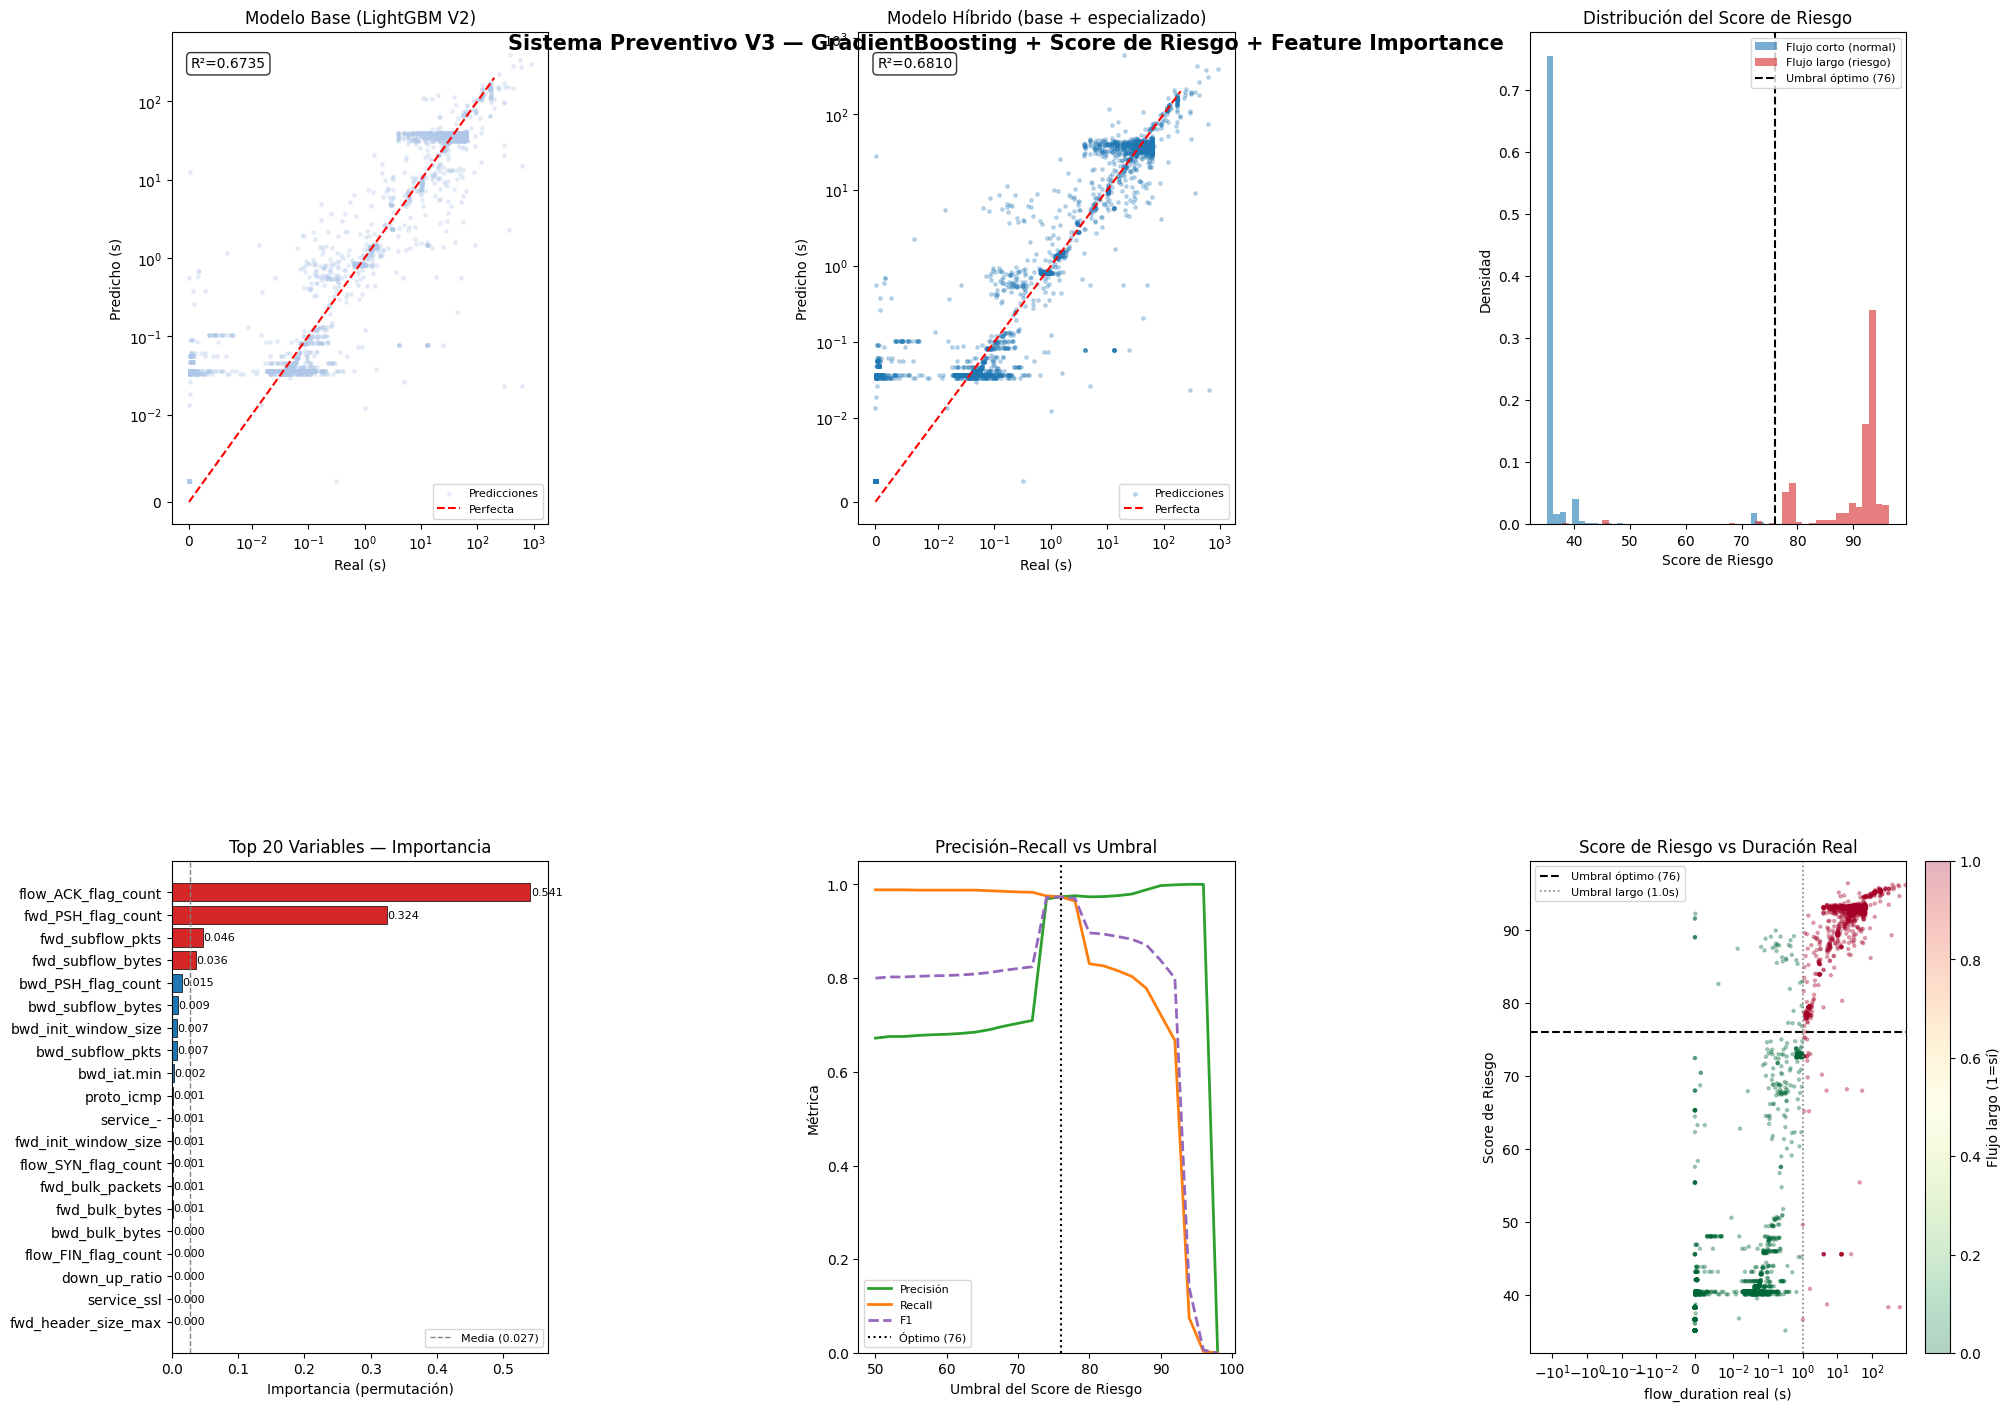

In [ ]:
fig = plt.figure(figsize=(20, 14), constrained_layout=True)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

fig.suptitle(
    'Sistema Preventivo V3 — GradientBoosting + Score de Riesgo + Feature Importance',
    fontsize=15, fontweight='bold', y=0.98
)

# ── Colores ──────────────────────────────────────────────────────────────
C_NORMAL  = '#1f77b4'
C_ALERTA  = '#d62728'
C_BASE    = '#aec7e8'
C_HIBRIDO = '#1f77b4'

# ─── Panel 1: Real vs Predicho — Modelo Base ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
mask_pos = (y_test_real.values > 0) & (predicciones_tiempo_gradient > 0)
ax1.scatter(y_test_real.values[mask_pos], predicciones_tiempo_gradient[mask_pos],
            alpha=0.25, s=6, color=C_BASE, label='Predicciones')
lim = [0, min(y_test_real.values[mask_pos].max(), 200)]
ax1.plot(lim, lim, 'r--', lw=1.5, label='Perfecta')
ax1.set_xscale('symlog', linthresh=0.01)
ax1.set_yscale('symlog', linthresh=0.01)
ax1.set_xlabel('Real (s)')
ax1.set_ylabel('Predicho (s)')
ax1.set_title('Modelo Base (LightGBM V2)')
r2_b = r2_score(y_test_real.values, predicciones_tiempo_gradient)
ax1.text(0.05, 0.95, f'R²={r2_b:.4f}', transform=ax1.transAxes,
         va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8), fontsize=10)
ax1.legend(fontsize=8)

# ─── Panel 2: Real vs Predicho — Modelo Híbrido ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test_real.values[mask_pos], pred_hibrido_real[mask_pos],
            alpha=0.25, s=6, color=C_HIBRIDO, label='Predicciones')
ax2.plot(lim, lim, 'r--', lw=1.5, label='Perfecta')
ax2.set_xscale('symlog', linthresh=0.01)
ax2.set_yscale('symlog', linthresh=0.01)
ax2.set_xlabel('Real (s)')
ax2.set_ylabel('Predicho (s)')
ax2.set_title('Modelo Híbrido (base + especializado)')
r2_h = r2_score(y_test_real.values, pred_hibrido_real)
ax2.text(0.05, 0.95, f'R²={r2_h:.4f}', transform=ax2.transAxes,
         va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8), fontsize=10)
ax2.legend(fontsize=8)

# ─── Panel 3: Score de riesgo — distribución ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(score_riesgo[~flujo_largo_real], bins=50, alpha=0.6,
         color=C_NORMAL, label='Flujo corto (normal)', density=True)
ax3.hist(score_riesgo[flujo_largo_real],  bins=50, alpha=0.6,
         color=C_ALERTA, label='Flujo largo (riesgo)', density=True)
ax3.axvline(mejor['umbral'], color='black', linestyle='--', lw=1.5,
            label=f'Umbral óptimo ({mejor["umbral"]:.0f})')
ax3.set_xlabel('Score de Riesgo')
ax3.set_ylabel('Densidad')
ax3.set_title('Distribución del Score de Riesgo')
ax3.legend(fontsize=8)

# ─── Panel 4: Feature Importances ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

# NOTA: Asegúrate de reemplazar 'modelo_base' o los datos de entrenamiento
# por la variable real que uses para tu modelo LightGBM.
perm_fi = permutation_importance(
    modelo_reg_gradient_boosting, X_train, y_train_log, # <-- ACTUALIZAR AQUÍ si cambió de nombre
    n_repeats=5, random_state=42, n_jobs=1,
    scoring='r2'
)
importancias_fi = np.clip(perm_fi.importances_mean, 0, None)
importancias_fi = importancias_fi / importancias_fi.sum() if importancias_fi.sum() > 0 else importancias_fi
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20

top_nombres_fi = [nombres[i] for i in indices_fi[:top_n]][::-1]
top_valores_fi = importancias_fi[indices_fi[:top_n]][::-1]
colores_fi     = ['#d62728' if v > importancias_fi.mean() else '#1f77b4' for v in top_valores_fi]

ax4.barh(top_nombres_fi, top_valores_fi, color=colores_fi, edgecolor='black', linewidth=0.5)
ax4.axvline(x=importancias_fi.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Media ({importancias_fi.mean():.3f})')
ax4.set_xlabel('Importancia (permutación)')
ax4.set_title(f'Top {top_n} Variables — Importancia')
ax4.legend(fontsize=8)
for i, v in enumerate(top_nombres_fi):
    ax4.text(top_valores_fi[i] + 0.001, i, f'{top_valores_fi[i]:.3f}', va='center', fontsize=8)

# ─── Panel 5: Precisión–Recall por umbral de score ───────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(df_umbral_gradient['umbral'], df_umbral_gradient['precision'], label='Precisión', color='#2ca02c', lw=2)
ax5.plot(df_umbral_gradient['umbral'], df_umbral_gradient['recall'],    label='Recall',    color='#ff7f0e', lw=2)
ax5.plot(df_umbral_gradient['umbral'], df_umbral_gradient['f1'],        label='F1',        color='#9467bd', lw=2, linestyle='--')
ax5.axvline(mejor['umbral'], color='black', linestyle=':', lw=1.5,
            label=f'Óptimo ({mejor["umbral"]:.0f})')
ax5.set_xlabel('Umbral del Score de Riesgo')
ax5.set_ylabel('Métrica')
ax5.set_title('Precisión–Recall vs Umbral')
ax5.legend(fontsize=8)
ax5.set_ylim(0, 1.05)

# ─── Panel 6: Score de riesgo vs duración real ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(
    y_test_real.values, score_riesgo,
    c=flujo_largo_real.astype(int), cmap='RdYlGn_r',
    alpha=0.3, s=5
)
ax6.axhline(mejor['umbral'], color='black', linestyle='--', lw=1.5,
            label=f'Umbral óptimo ({mejor["umbral"]:.0f})')
ax6.axvline(UMBRAL_LARGO, color='gray', linestyle=':', lw=1.2,
            label=f'Umbral largo ({UMBRAL_LARGO}s)')
ax6.set_xscale('symlog', linthresh=0.01)
ax6.set_xlabel('flow_duration real (s)')
ax6.set_ylabel('Score de Riesgo')
ax6.set_title('Score de Riesgo vs Duración Real')
ax6.legend(fontsize=8)
plt.colorbar(sc, ax=ax6, label='Flujo largo (1=sí)')

plt.show()

Metodo de validacion



In [ ]:
mask = ~np.isnan(y_log)
X_cv     = X[mask]
y_log_cv = y_log[mask]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(modelo_reg_gradient_boosting, X_cv, y_log_cv, cv=cv,
                        scoring={'r2' : 'r2',
                                 'mae': 'neg_mean_absolute_error',
                                 'mse': 'neg_mean_squared_error'},
                        n_jobs=-1)

r2_v   =  cv_res['test_r2']
mae_v  = -cv_res['test_mae']
rmse_v =  np.sqrt(-cv_res['test_mse'])

print("\n" + "="*52)
print("  VALIDACIÓN CRUZADA — GradientBoostingRegressor (5 folds)")
print("="*52)
print(f"  {'Fold':<8} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"  {'-'*42}")
for i, (r2, mae, rmse) in enumerate(zip(r2_v, mae_v, rmse_v)):
    print(f"  Fold {i+1}    {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")
print(f"  {'-'*42}")
print(f"  {'Media':<8} {r2_v.mean():>8.4f} {mae_v.mean():>10.4f} {rmse_v.mean():>10.4f}")
print(f"  {'Std':<8} {r2_v.std():>8.4f} {mae_v.std():>10.4f} {rmse_v.std():>10.4f}")
print("="*52)


  VALIDACIÓN CRUZADA — GradientBoostingRegressor (5 folds)
  Fold           R²        MAE       RMSE
  ------------------------------------------
  Fold 1      0.9481     0.0359     0.1855
  Fold 2      0.9610     0.0307     0.1580
  Fold 3      0.9639     0.0312     0.1526
  Fold 4      0.9610     0.0324     0.1588
  Fold 5      0.9626     0.0322     0.1586
  ------------------------------------------
  Media      0.9593     0.0325     0.1627
  Std        0.0057     0.0018     0.0116


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(modelo_reg_GBM, X_cv, y_log_cv, cv=cv,
                        scoring={'r2' : 'r2',
                                 'mae': 'neg_mean_absolute_error',
                                 'mse': 'neg_mean_squared_error'},
                        n_jobs=-1)

r2_v   =  cv_res['test_r2']
mae_v  = -cv_res['test_mae']
rmse_v =  np.sqrt(-cv_res['test_mse'])

print("\n" + "="*52)
print("  VALIDACIÓN CRUZADA — LIGHT GBM (5 folds)")
print("="*52)
print(f"  {'Fold':<8} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"  {'-'*42}")
for i, (r2, mae, rmse) in enumerate(zip(r2_v, mae_v, rmse_v)):
    print(f"  Fold {i+1}    {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")
print(f"  {'-'*42}")
print(f"  {'Media':<8} {r2_v.mean():>8.4f} {mae_v.mean():>10.4f} {rmse_v.mean():>10.4f}")
print(f"  {'Std':<8} {r2_v.std():>8.4f} {mae_v.std():>10.4f} {rmse_v.std():>10.4f}")
print("="*52)


  VALIDACIÓN CRUZADA — LIGHT GBM (5 folds)
  Fold           R²        MAE       RMSE
  ------------------------------------------
  Fold 1      0.9542     0.0301     0.1743
  Fold 2      0.9670     0.0248     0.1454
  Fold 3      0.9668     0.0259     0.1462
  Fold 4      0.9653     0.0268     0.1499
  Fold 5      0.9686     0.0262     0.1453
  ------------------------------------------
  Media      0.9644     0.0268     0.1522
  Std        0.0052     0.0018     0.0111
